#  Crop Recommendation System - Exploratory Data Analysis (EDA)
---
### Objective:
Perform detailed EDA on the **Crop Recommendation Dataset** to understand the distribution, correlation, and relationships between soil nutrients, climate conditions, and recommended crops.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
%matplotlib inline

In [2]:
# Load dataset
data = pd.read_csv('../data/Crop_recommendation.csv')
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
# Basic info
print('Shape of dataset:', data.shape)
print('Data types:',data.dtypes)
print('Missing values:',data.isnull().sum())

Shape of dataset: (2200, 8)
Data types: N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object
Missing values: N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [6]:
# Statistical summary
data.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


# Target Variable Analysis (Crop Label)
## Count of each crop: 
* Dataset is balanced (almost equal samples per crop).
* Each crop has ~100 samples.

In [7]:
data['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

## Categorical Feature: Crop Label Distribution

<Figure size 1200x600 with 0 Axes>

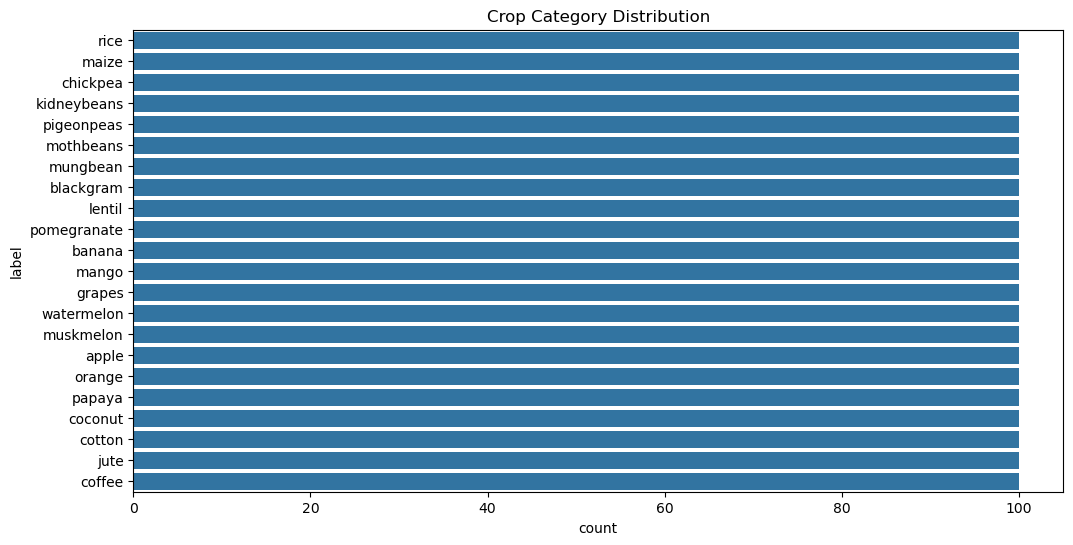

In [18]:
plt.figure(figsize=(12,6))
sns.countplot(y=data['label'], order=data['label'].value_counts().index)
plt.title("Crop Category Distribution")
plt.show()

## Univariate Analysis (Single Column Analysis)
* Numerical Feature Distribution (Histogram)

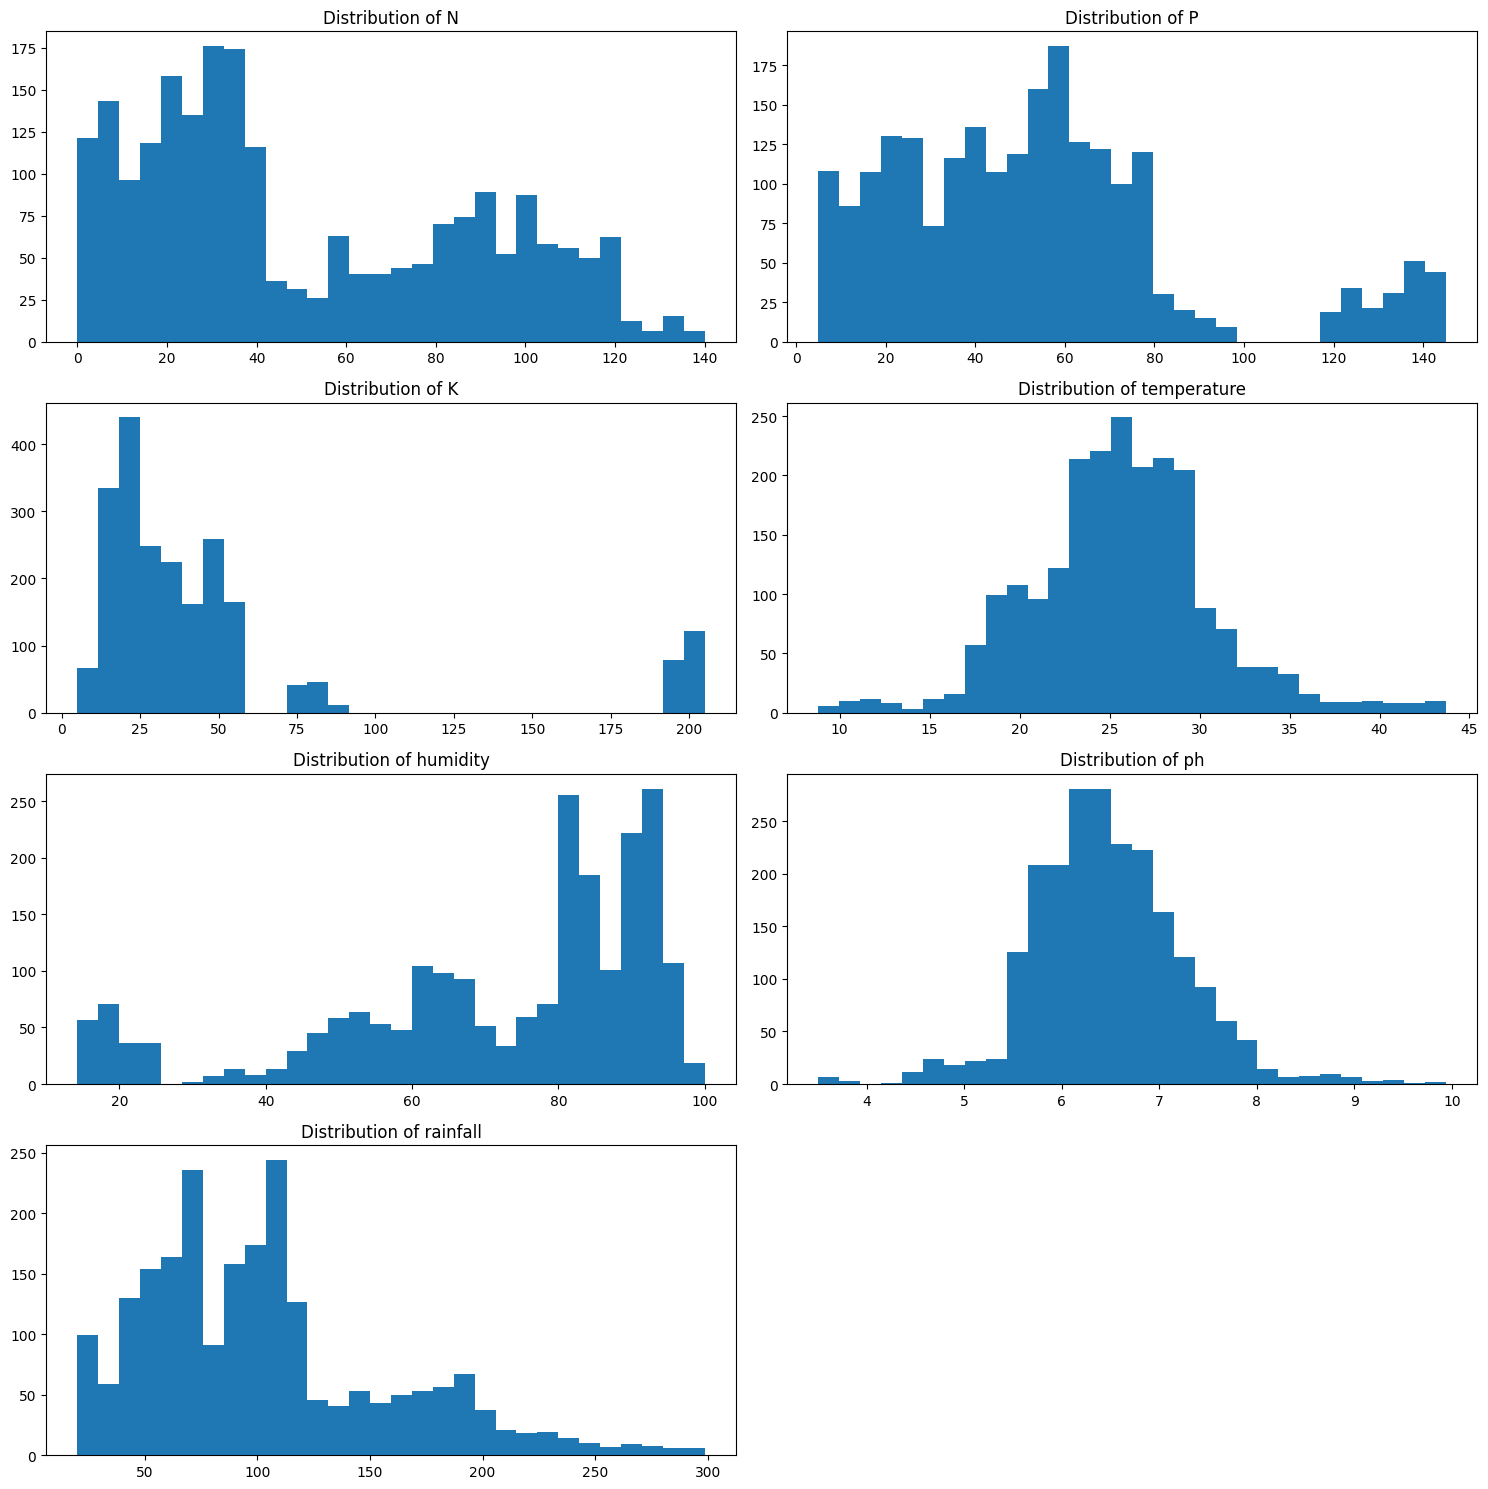

In [8]:
num_cols = ['N','P','K','temperature','humidity','ph','rainfall']
plt.figure(figsize=(15, 15))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 2, i)
    plt.hist(data[col], bins=30)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

## Bivariate Analysis (Feature vs Crop Label)
* Boxplots: How each feature varies with crop type 
* Helps identify which nutrients or climate features decide crop.

 ##  How to Read the Boxplots (Feature vs Crop Label)

The boxplots you generated show how **each numerical feature** (N, P, K, temperature, humidity, ph, rainfall) varies across **different crop types**.

Here is how to correctly interpret them:

---

### What Each Boxplot Represents

- **x-axis:** Crop label (rice, wheat, mango, etc.)
- **y-axis:** Value of the feature (N, P, K, etc.)
- **Each box:** Distribution of that feature for that crop

For example:  
A tall box for “Rice” in the *rainfall* plot means rice requires high rainfall.

---

###  What Each Part of the Box Means

Boxplots display **statistical spread**:

- **Top whisker:** Maximum value  
- **Upper box:** Q3 (75th percentile)  
- **Middle line:** Median (50th percentile)  
- **Lower box:** Q1 (25th percentile)  
- **Bottom whisker:** Minimum  
- **Dots outside whiskers:** Outliers (rare in your dataset)

---

### What to Look For (Interpretation Guide)

####  1. Compare medians
If the **median line** is high for a crop:
- That crop needs **higher value** of that feature.

Example:  
If “Banana” has the highest median rainfall → bananas need high rainfall.

---

#### 2. Compare box height (IQR)
A **taller box** = more variation in that feature.

- Tall box → crop tolerates a wide range  
- Short box → crop needs very specific range

---

#### 3. Compare crops side-by-side
You can easily see which crops prefer:

- High Nitrogen (N)
- Low Potassium (K)
- Moderate temperature
- High humidity
- Acidic or alkaline pH
- High rainfall

---

### 4. How to Interpret for Your Crop Dataset

Looking at your plots, you will see:

#### **Nutrient Features (N, P, K)**
- Some crops have **very high N values**, others low →  
  **N is a very important distinguishing feature.**

- K also varies significantly across crops →  
  **Strong feature for classification.**

#### **Temperature**
- Crops cluster into:
  - Cool climate crops  
  - Moderate climate crops  
  - Hot climate crops  

#### **Humidity**
- Some crops need dry weather  
- Others need highly humid conditions

#### **pH**
- Some crops prefer acidic (low pH)  
- Others neutral or alkaline (high pH)

#### **Rainfall**
- Rainfall has the **strongest separation**  
  → Each crop has a clear preferred rainfall range

---

###  5. Why Boxplots Are Helpful in ML

Boxplots help you identify:

-  **Feature importance (visually)**  
- **Outliers or weird patterns**  
-  **Which features separate crops clearly**  
-  **Range differences that ML models can learn**

---

### Final Summary

Your boxplots show that **N**, **P**, **K**, **temperature**, **ph**, and **rainfall** all have **clear differences between crops**.

➡ These features will strongly help your classification model.  
➡ Boxplots confirm this dataset is **excellent for ML**.

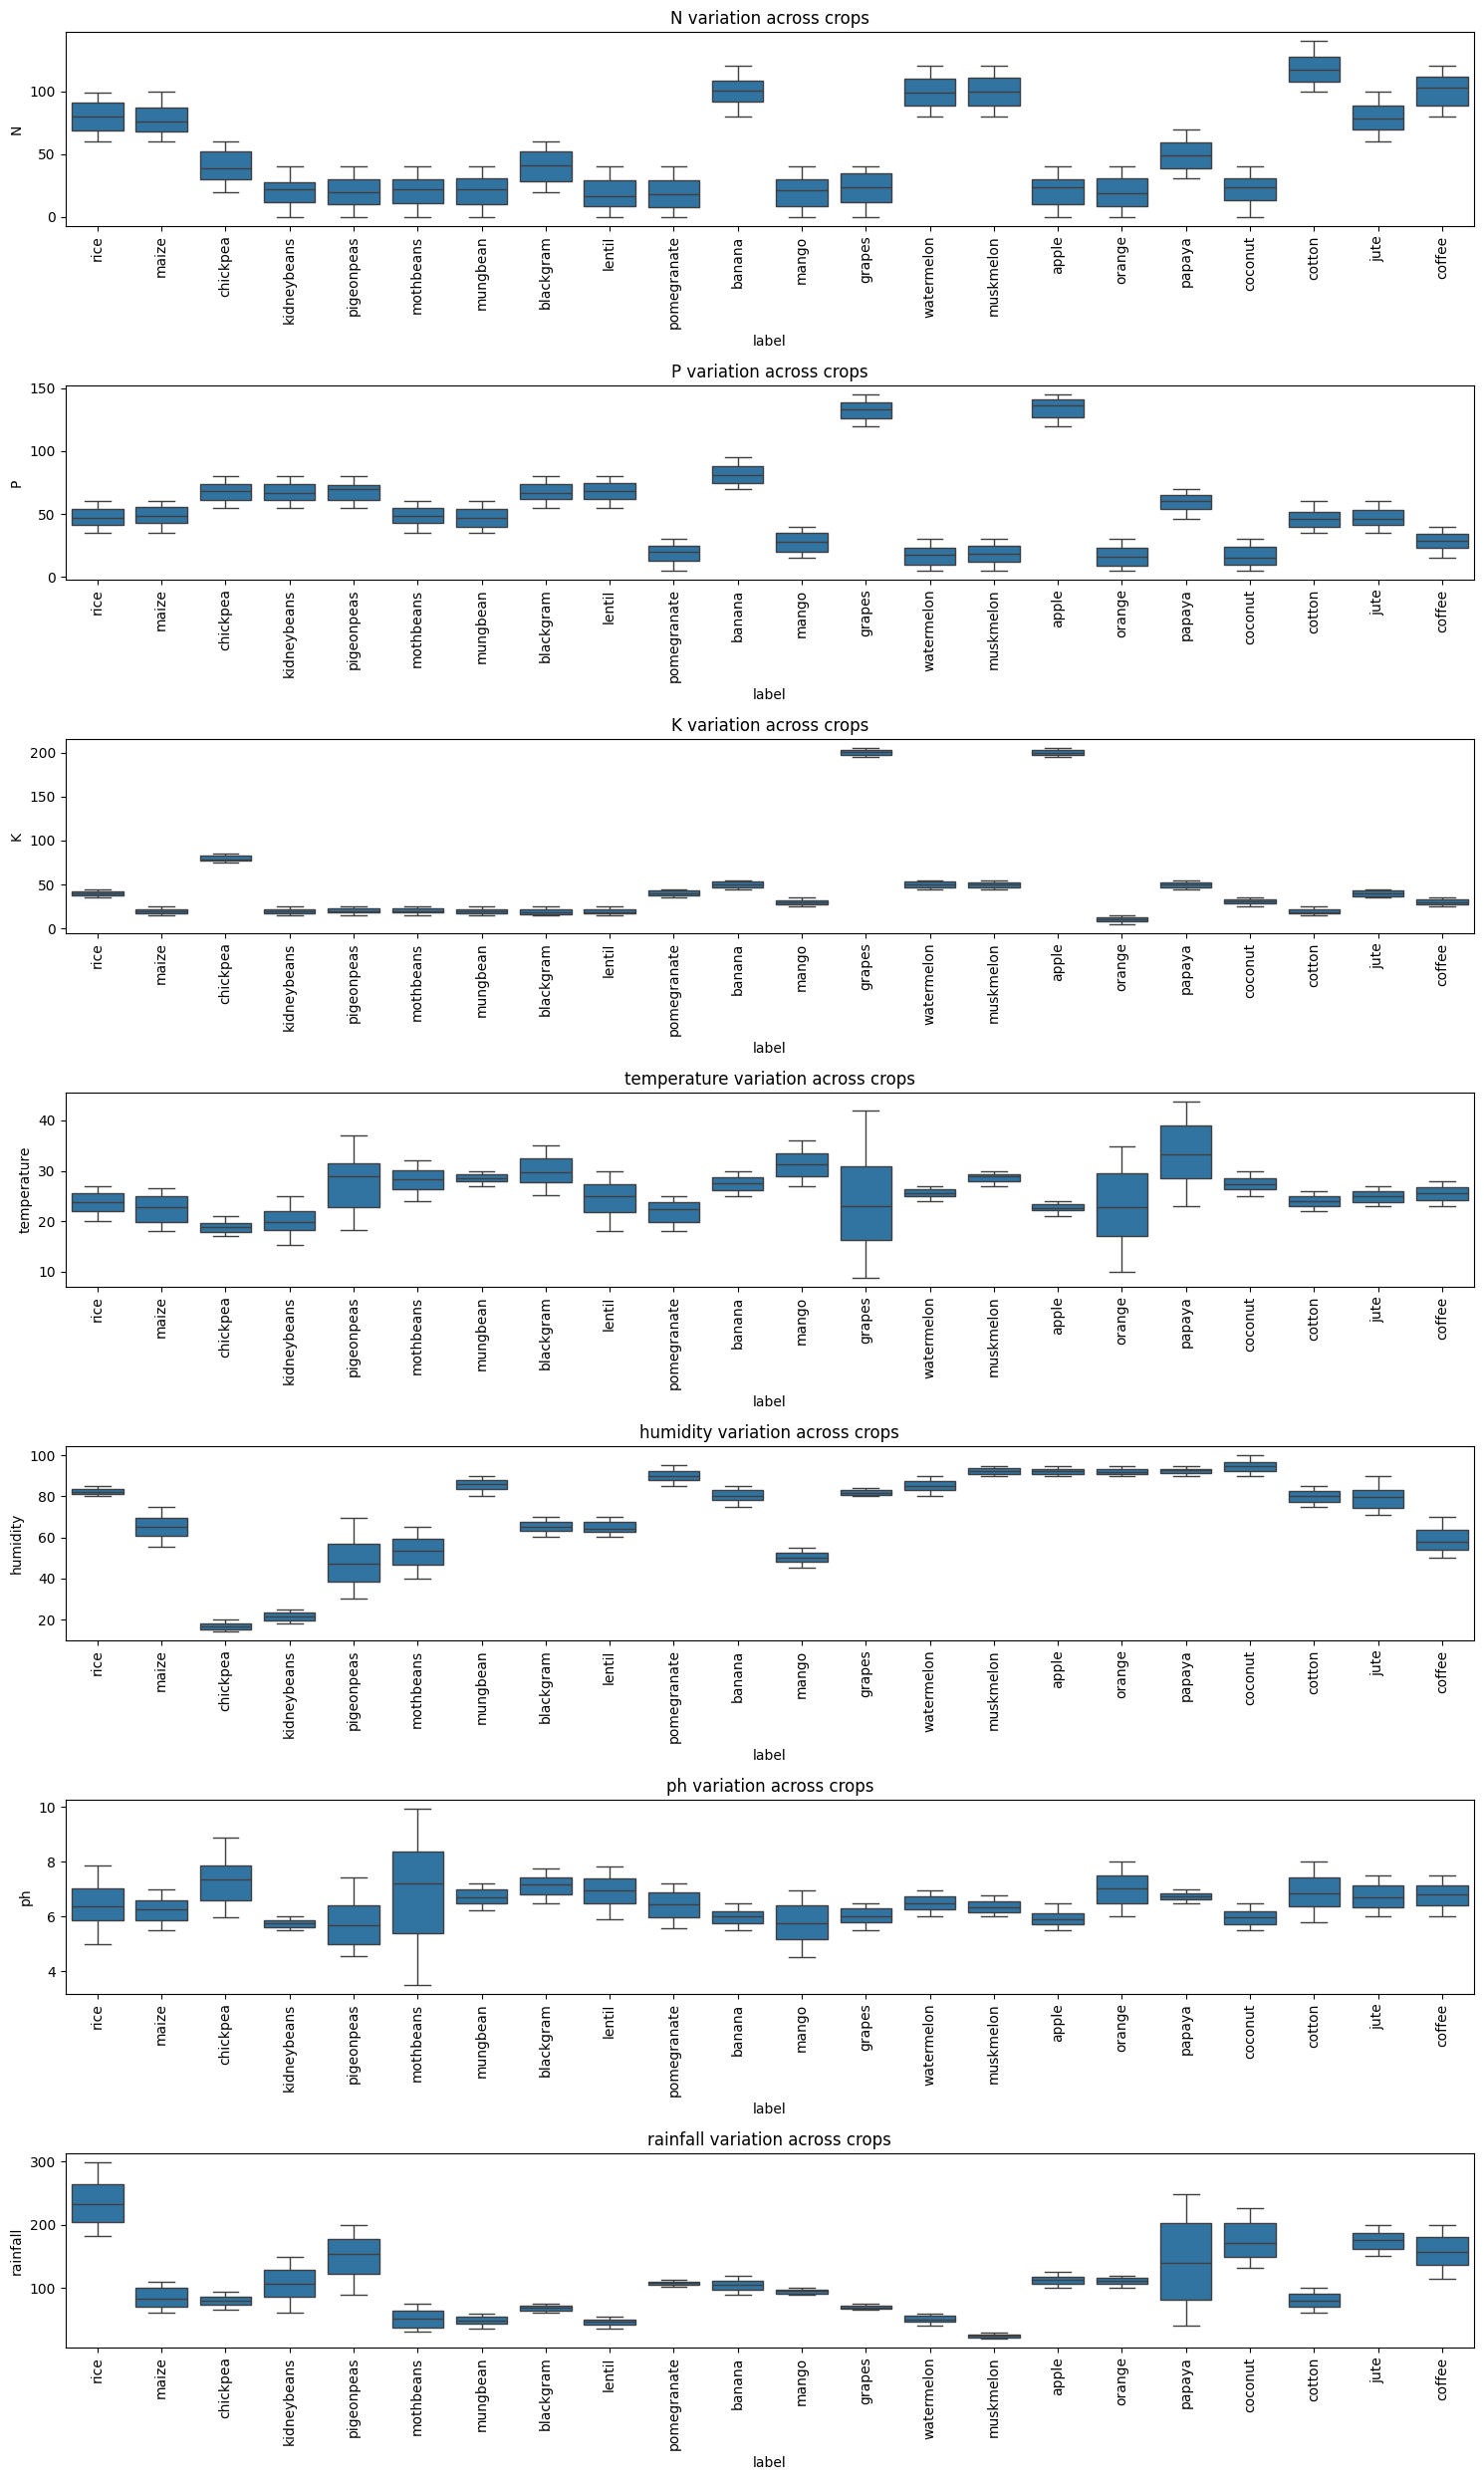

In [13]:
plt.figure(figsize=(15, 25))
for i, col in enumerate(num_cols, 1):
    plt.subplot(7, 1, i)
    sns.boxplot(x='label', y=col, data=data)
    plt.xticks(rotation=90)
    plt.title(f"{col} variation across crops")
plt.tight_layout()
plt.show()

## Correlation Analysis 
## How to Read the Correlation Heatmap (YlGnBu)

### 1. Color Interpretation (YlGnBu Colormap)

The **YlGnBu colormap** represents correlation values using colors:

- **Yellow / Light Green → High Positive Correlation**
- **Dark Green → Medium Correlation**
- **Blue → Low or Negative Correlation**

Meaning:
- **Lighter colors = stronger positive relationship**
- **Darker colors = weaker or negative relationship**

---

### 2. Number Interpretation (`annot=True`)

Each heatmap cell shows a number between **-1.00 to +1.00**:

| Correlation Value | Meaning |
|------------------|---------|
| **+1.00** | Perfect positive relationship |
| **+0.70 to +1.00** | Strong positive correlation |
| **+0.40 to +0.69** | Moderate correlation |
| **+0.10 to +0.39** | Weak correlation |
| **0.00 to +0.09** | Very weak / no correlation |
| **-0.10 to -1.00** | Negative correlation |

---

### 3. How to Read Each Heatmap Cell

Each box compares **two numerical features**.

Example:

| temperature | rainfall | **0.25** |

Meaning:
- Temperature increases → rainfall increases **slightly**  
- **Weak correlation**

---

### 4. Interpretation for Your Crop Recommendation Dataset

After observing your heatmap:

-  Most correlations lie between **0.0 and 0.3**
  **Weak or no linear relationship**

- No correlation is above **0.7**
  → **No multicollinearity**

-  Features such as **N, P, K, temperature, humidity, ph, rainfall**  
  are **mostly independent**

 **Each feature provides unique information to the ML model.**

---

### 5. What You Should Look For (Checklist)

**Strong correlations (0.7+)**  
→ Consider removing/combining features  
*Your dataset has none → Perfect.*

**Negative correlations (-0.5 or lower)**  
→ Opposite relationships  
 Almost none present.

**Diagonal values = 1**  
→ A feature correlated with itself  
→ Normal.

---

### 6. Final Interpretation for ML

**Main takeaway: Your dataset features are independent.**

This means:

-  No redundant features  
-  No multicollinearity  
-  Each feature helps the model uniquely  
-  **Tree-based models (RandomForest, XGBoost) will perform extremely well**  
-  Good for classification because patterns are easy for a model to detect  

---

### Summary

Your correlation heatmap shows that the dataset is **clean, independent, and ML-friendly**.

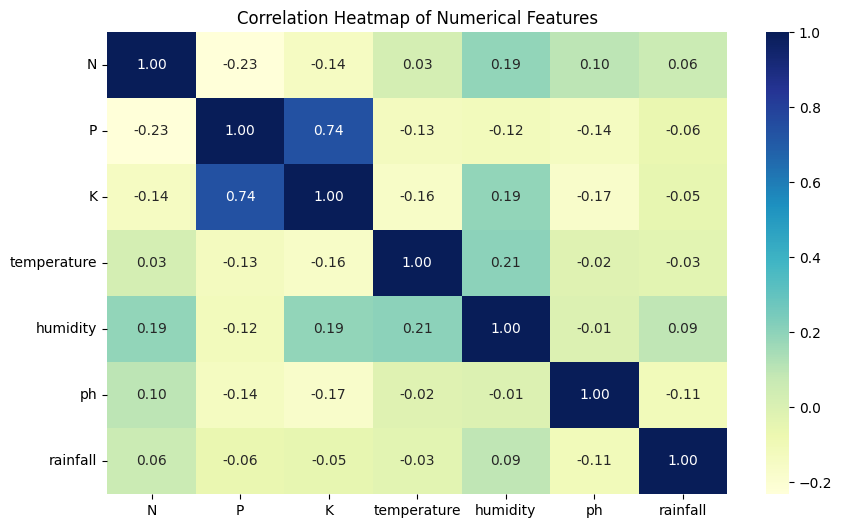

In [16]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# EDA Insights Summary (Crop Recommendation Dataset)

## 1. Dataset Balance
- Each crop category contains **100 samples**.
- The dataset is **perfectly balanced**.
- No need for class imbalance techniques (SMOTE / undersampling / oversampling).

---

## 2. Nutrient Patterns (N, P, K)
- `N`, `P`, and `K` vary **strongly across different crops**.
- These nutrient values are **highly informative** for crop classification.
- They will be **key features** for ML models.

---

## 3. Climate Features (Temperature & Rainfall)
- Crops show **distinct temperature ranges**.
- Rainfall also varies significantly across crop labels.
- These climate variables help identify the most suitable crop for given conditions.

---

## 4. Soil pH Variation
- pH ranges from **3.5 to 9.9**.
- Some crops prefer **acidic** soil (pH < 6), others prefer **alkaline** soil (pH > 7).
- pH provides strong separation between crop types.

---

## 5. Correlation Structure
- Correlation among features is **low to moderate**.
- No multicollinearity issues.
- Great for ML models, especially **tree-based classifiers**.

---

## 6. Data Quality Check
- **No missing values** in any column.
- All columns have the correct data types.
- Dataset is **well-structured and clean**.
- Minimal preprocessing required.

---

## Summary
Overall, the dataset is **balanced, clean, and highly suitable for machine learning**.  
The strongest features for prediction include:
- Nutrients: `N`, `P`, `K`
- Climate: `temperature`, `humidity`, `rainfall`
- Soil: `ph`

This EDA confirms that the dataset is ready for **model building and feature engineering**.